# Модель SIR в виде сети Петри: итоговые графики

Скрипт читает результаты, сохранённые предыдущими скриптами,
и строит два графика: сравнение детерминированной и стохастической
динамики и зависимость пика от $\beta$.
Перед запуском должны быть выполнены скрипты `sirpetri_run.jl`
и `sirpetri_scan_parameters.jl`.

## Активация проекта и загрузка пакетов

In [1]:
using DrWatson
@quickactivate "project"
using DataFrames, CSV, Plots

script_name = "sirpetri_report"
mkpath(plotsdir())

"/home/iaberezhnoy/work/study/2026-1/2026-1==study--simulation-modeling/2026-1--study--simulation-modeling/labs/lab06/project/plots"

## Чтение данных

In [2]:
df_det = CSV.read(datadir("sir_det.csv"), DataFrame)
df_stoch = CSV.read(datadir("sir_stoch.csv"), DataFrame)
df_scan = CSV.read(datadir("sir_scan.csv"), DataFrame)
(nrow(df_det), nrow(df_stoch), nrow(df_scan))

(201, 1991, 15)

## Сравнение детерминированной и стохастической динамики

У двух таблиц разные моменты времени, поэтому каждая кривая
строится по своему столбцу времени.

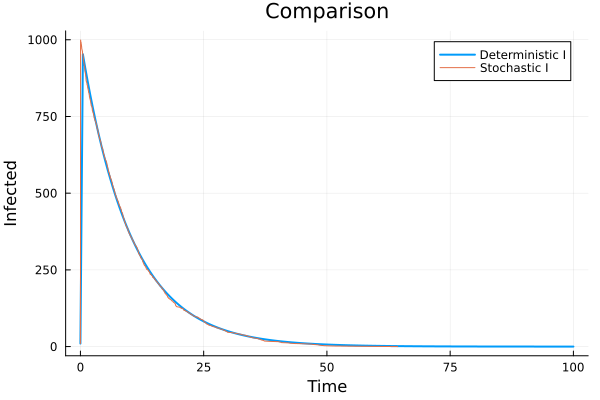

In [3]:
p1 = plot(
    df_det.time,
    df_det.I,
    label = "Deterministic I",
    xlabel = "Time",
    ylabel = "Infected",
    title = "Comparison",
    linewidth = 2,
)
plot!(p1, df_stoch.time, df_stoch.I, label = "Stochastic I")
savefig(p1, plotsdir("comparison.png"))
p1

## Зависимость пика I от β

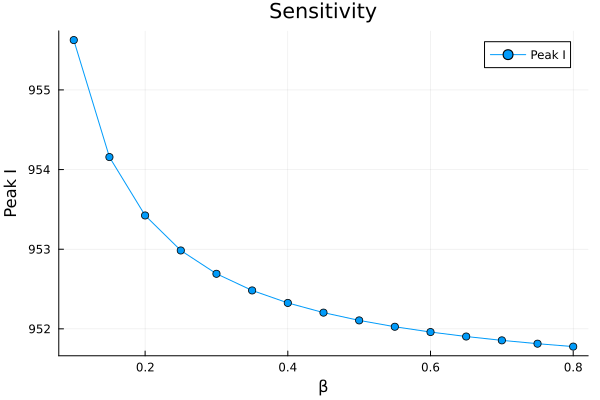

In [4]:
p2 = plot(
    df_scan.β,
    df_scan.peak_I,
    marker = :circle,
    label = "Peak I",
    xlabel = "β",
    ylabel = "Peak I",
    title = "Sensitivity",
)
savefig(p2, plotsdir("sensitivity.png"))
p2

## Итог

In [5]:
println("Отчётные графики сохранены в plots/")

Отчётные графики сохранены в plots/
